In [ ]:
# Import Libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression 
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_squared_error, r2_score

In [80]:
# Load Datasets

data = pd.read_csv("../data/Hyderbad_House_price.csv")
data = data.drop(columns=["Unnamed: 0"], errors="ignore")
data

,title,location,price(L),rate_persqft,area_insqft,building_status
0,3 BHK Apartment,Nizampet,108.00,6000,1805,Under Construction
1,3 BHK Apartment,Bachupally,85.80,5500,1560,Under Construction
2,2 BHK Apartment,Dundigal,55.64,5200,1070,Under Construction
3,2 BHK Apartment,Pocharam,60.48,4999,1210,Under Construction
4,3 BHK Apartment,Kollur,113.00,5999,1900,Under Construction
...,...,...,...,...,...,...
3655,2 BHK Apartment,Ameerpet,60.00,6000,1000,Ready to move
3656,2 BHK Independent House,Jawahar nagar,65.00,3250,2000,Ready to move
3657,2 BHK Independent Floor,Rasoolpura,65.00,6500,1000,Ready to move
3658,2 BHK Independent Floor,Begum Bazar Chatri,55.00,5500,1000,Ready to move


In [82]:
# Feature Engineering 

data["bhk"] = data["title"].str.extract(r'(\d+)').astype(float)
data["property_type"] = data["title"].str.extract(r'(Apartment|House|Plot|Villa|Floor)')

le = LabelEncoder()
data["building_status_encoded"] = le.fit_transform(data["building_status"])

# Frequency encoding for location (too many categories for one-hot)
data["location_encoded"] = data["location"].map(data["location"].value_counts())

data["price_per_sqft"] = (data["price(L)"] * 100000) / data["area_insqft"]
data

,title,location,price(L),rate_persqft,area_insqft,building_status,bhk,property_type,building_status_encoded,location_encoded,price_per_sqft
0,3 BHK Apartment,Nizampet,108.00,6000,1805,Under Construction,3.0,Apartment,3,18,5983.379501
1,3 BHK Apartment,Bachupally,85.80,5500,1560,Under Construction,3.0,Apartment,3,67,5500.000000
2,2 BHK Apartment,Dundigal,55.64,5200,1070,Under Construction,2.0,Apartment,3,12,5200.000000
3,2 BHK Apartment,Pocharam,60.48,4999,1210,Under Construction,2.0,Apartment,3,10,4998.347107
4,3 BHK Apartment,Kollur,113.00,5999,1900,Under Construction,3.0,Apartment,3,58,5947.368421
...,...,...,...,...,...,...,...,...,...,...,...
3655,2 BHK Apartment,Ameerpet,60.00,6000,1000,Ready to move,2.0,Apartment,1,2,6000.000000
3656,2 BHK Independent House,Jawahar nagar,65.00,3250,2000,Ready to move,2.0,House,1,1,3250.000000
3657,2 BHK Independent Floor,Rasoolpura,65.00,6500,1000,Ready to move,2.0,Floor,1,2,6500.000000
3658,2 BHK Independent Floor,Begum Bazar Chatri,55.00,5500,1000,Ready to move,2.0,Floor,1,1,5500.000000


In [ ]:
# Train and Split Data

features = ["rate_persqft", "area_insqft", "bhk", "building_status_encoded", "location_encoded", "price_per_sqft"]

X = data[features].fillna(0)
y=data["price(L)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

train_data = X_train.join(y_train)

,rate_persqft,area_insqft,bhk,building_status_encoded,location_encoded,price_per_sqft,price(L)
1966,1022,1062,0.0,0,140,1021.657250,10.85
570,5045,1100,2.0,3,21,5045.454545,55.50
3388,4093,1700,3.0,3,16,4092.941176,69.58
343,2222,1800,0.0,0,18,2221.666667,39.99
3408,4615,2600,3.0,3,23,4615.384615,120.00
...,...,...,...,...,...,...,...
1130,7200,1500,2.0,3,36,7200.000000,108.00
1294,6700,2325,3.0,3,62,6666.666667,155.00
860,9505,1567,3.0,3,6,9444.798979,148.00
3507,8510,1410,2.0,1,107,8510.638298,120.00


array([[<Axes: title={'center': 'rate_persqft'}>,
        <Axes: title={'center': 'area_insqft'}>,
        <Axes: title={'center': 'bhk'}>],
       [<Axes: title={'center': 'building_status_encoded'}>,
        <Axes: title={'center': 'location_encoded'}>,
        <Axes: title={'center': 'price_per_sqft'}>],
       [<Axes: title={'center': 'price(L)'}>, <Axes: >, <Axes: >]],
      dtype=object)

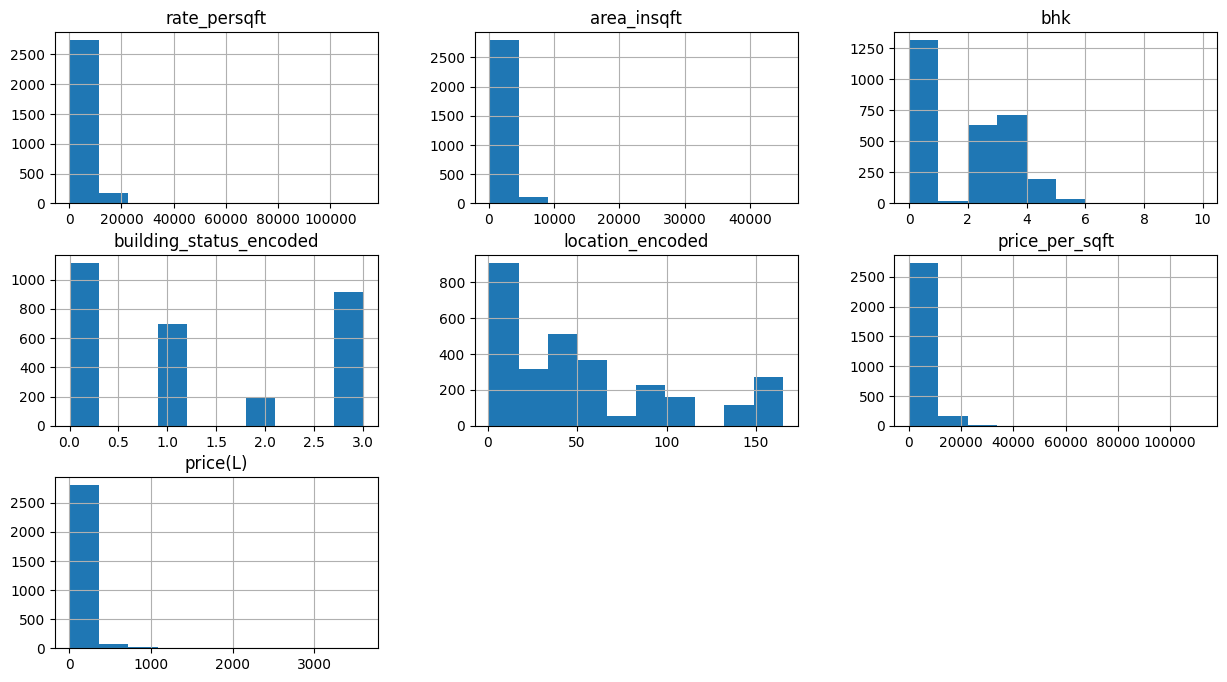

In [ ]:
# Data Visualization
train_data.hist(figsize=(15,8))

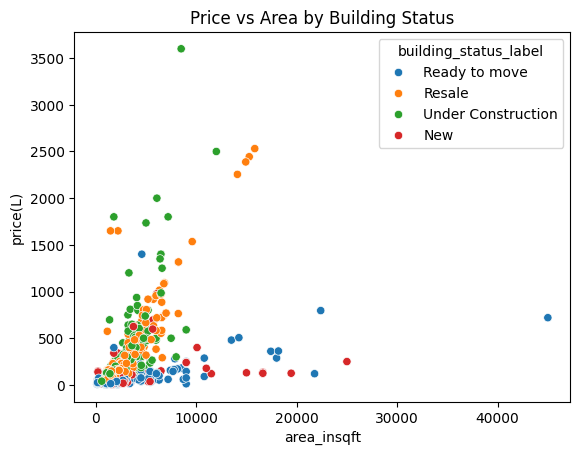

In [96]:
status_map = {0: "Ready to move", 
              1: "Under Construction", 
              2: "New", 
              3: "Resale"}

train_data["building_status_label"] = train_data["building_status_encoded"].map(status_map)

sns.scatterplot(x="area_insqft", y="price(L)", data=train_data, hue="building_status_label")
plt.title("Price vs Area by Building Status")
plt.show()

In [ ]:
# Scale Features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)


In [ ]:
# Train Model - Linear Regression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear Regression R2: 0.7178806265557743
Linear Regression RMSE: 103.49641363549813


In [ ]:
# Traim Model - Random Forest

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)   # RF doesn’t need scaling

y_pred_rf = rf.predict(X_test)
print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Random Forest R2: 0.9537332221167036
Random Forest RMSE: 41.91249100268035
